# Real-Time Bahasa Isyarat Malaysia (BIM) Recognition System
### YOLOv11 + MediaPipe Hybrid | BICS 4340 Machine Learning | Group G
**Members:** Iman Zafri (2414499) | Muhammad Aizam (2410687) | Adam Fawwaz (2416969) | Muhammad Iman Imtiyaz (2415293)  
**Lecturer:** Prof. Dr. Amelia Ritahani binti Ismail  
**Dataset:** [Malaysian Sign Language (MSL) Image Dataset – Kaggle](https://www.kaggle.com/datasets/pradeepisawasan/malaysian-sign-language-msl-image-dataset)

## Section 1 — Setup & Installation

In [34]:
# Install required packages (run once)
# On M1/M2 Mac, MPS acceleration is used automatically by PyTorch & Ultralytics
import subprocess, sys

packages = [
    'ultralytics',       # YOLOv11
    'mediapipe',         # Hand keypoint tracking
    'scikit-learn',      # SVM, RF, KNN
    'matplotlib',
    'seaborn',
    'pandas',
    'numpy',
    'Pillow',
    'torch',
    'torchvision',
    'tqdm',
    'joblib',
]

for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
print('All packages installed.')

You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3

All packages installed.


You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


In [35]:
import os, shutil, warnings, random, json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from pathlib import Path
from PIL import Image
from tqdm import tqdm
import joblib
import cv2

# MediaPipe
import mediapipe as mp

# Scikit-learn
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, confusion_matrix)
from sklearn.pipeline import Pipeline

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Ultralytics YOLOv11
from ultralytics import YOLO

warnings.filterwarnings('ignore')
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

# ── Device detection (MPS for M1 Mac, CUDA for NVIDIA, else CPU)
if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
    print('Device: Apple MPS (M1/M2 GPU)')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
    print(f'Device: CUDA ({torch.cuda.get_device_name(0)})')
else:
    DEVICE = torch.device('cpu')
    print('Device: CPU')

# ── Paths
BASE_DIR      = Path('.')
DATASET_DIR   = BASE_DIR / 'dataset'
MODELS_DIR    = BASE_DIR / 'models'
YOLO_DATA_DIR = BASE_DIR / 'yolo_dataset'
MODELS_DIR.mkdir(exist_ok=True)
print('Paths ready.')

Device: Apple MPS (M1/M2 GPU)
Paths ready.


## Section 2 — Dataset Setup

**Download instructions:**
1. Go to: https://www.kaggle.com/datasets/pradeepisawasan/malaysian-sign-language-msl-image-dataset
2. Click **Download** → extract the zip
3. Place the extracted folder so the structure looks like:
```
dataset/
  A/  B/  C/  ...  (one folder per BIM sign class)
```
4. Then run the cells below.

In [36]:
# ── Discover dataset structure (handles MSL nested layout)
assert DATASET_DIR.exists(), f'Dataset folder not found at {DATASET_DIR}'

IMG_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp'}

# MSL dataset has: dataset/Dataset_MSL/Dataset_MSL/Alphabet_MSL/ and Number_MSL/
# Flatten all leaf class folders regardless of nesting
def find_class_dirs(root: Path):
    """Return list of (class_name, path) for all leaf dirs containing images."""
    results = []
    for d in sorted(root.rglob('*')):
        if d.is_dir():
            imgs = [f for f in d.iterdir() if f.suffix.lower() in IMG_EXTENSIONS]
            if imgs:  # leaf dir with images
                results.append((d.name, d))
    return results

class_dir_pairs = find_class_dirs(DATASET_DIR)
CLASSES = [name for name, _ in class_dir_pairs]
NUM_CLASSES = len(CLASSES)
class_dir_map = {name: path for name, path in class_dir_pairs}

print(f'Classes found ({NUM_CLASSES}): {CLASSES}')

class_counts = {}
all_image_paths = []
all_labels = []

for cls, cls_path in class_dir_map.items():
    imgs = [f for f in cls_path.iterdir() if f.suffix.lower() in IMG_EXTENSIONS]
    class_counts[cls] = len(imgs)
    all_image_paths.extend(imgs)
    all_labels.extend([cls] * len(imgs))

total_images = sum(class_counts.values())
print(f'Total images: {total_images}')
print(f'Min per class: {min(class_counts.values())} | Max: {max(class_counts.values())}')


Classes found (29): ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', '0', '1', '10']
Total images: 9586
Min per class: 136 | Max: 350


## Section 3 — Exploratory Data Analysis (EDA)

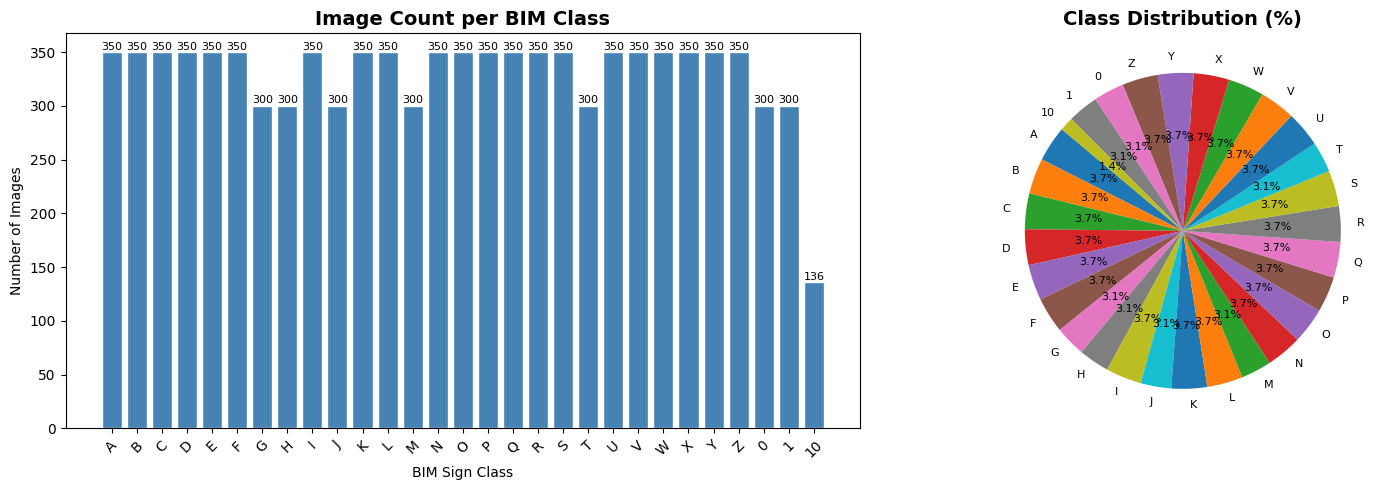

EDA plot saved.


In [37]:
# ── Class distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart
ax = axes[0]
bars = ax.bar(class_counts.keys(), class_counts.values(), color='steelblue', edgecolor='white')
ax.set_title('Image Count per BIM Class', fontsize=14, fontweight='bold')
ax.set_xlabel('BIM Sign Class')
ax.set_ylabel('Number of Images')
ax.tick_params(axis='x', rotation=45)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=8)

# Pie chart
ax2 = axes[1]
ax2.pie(class_counts.values(), labels=class_counts.keys(),
        autopct='%1.1f%%', startangle=140, textprops={'fontsize': 8})
ax2.set_title('Class Distribution (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(MODELS_DIR / 'eda_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('EDA plot saved.')

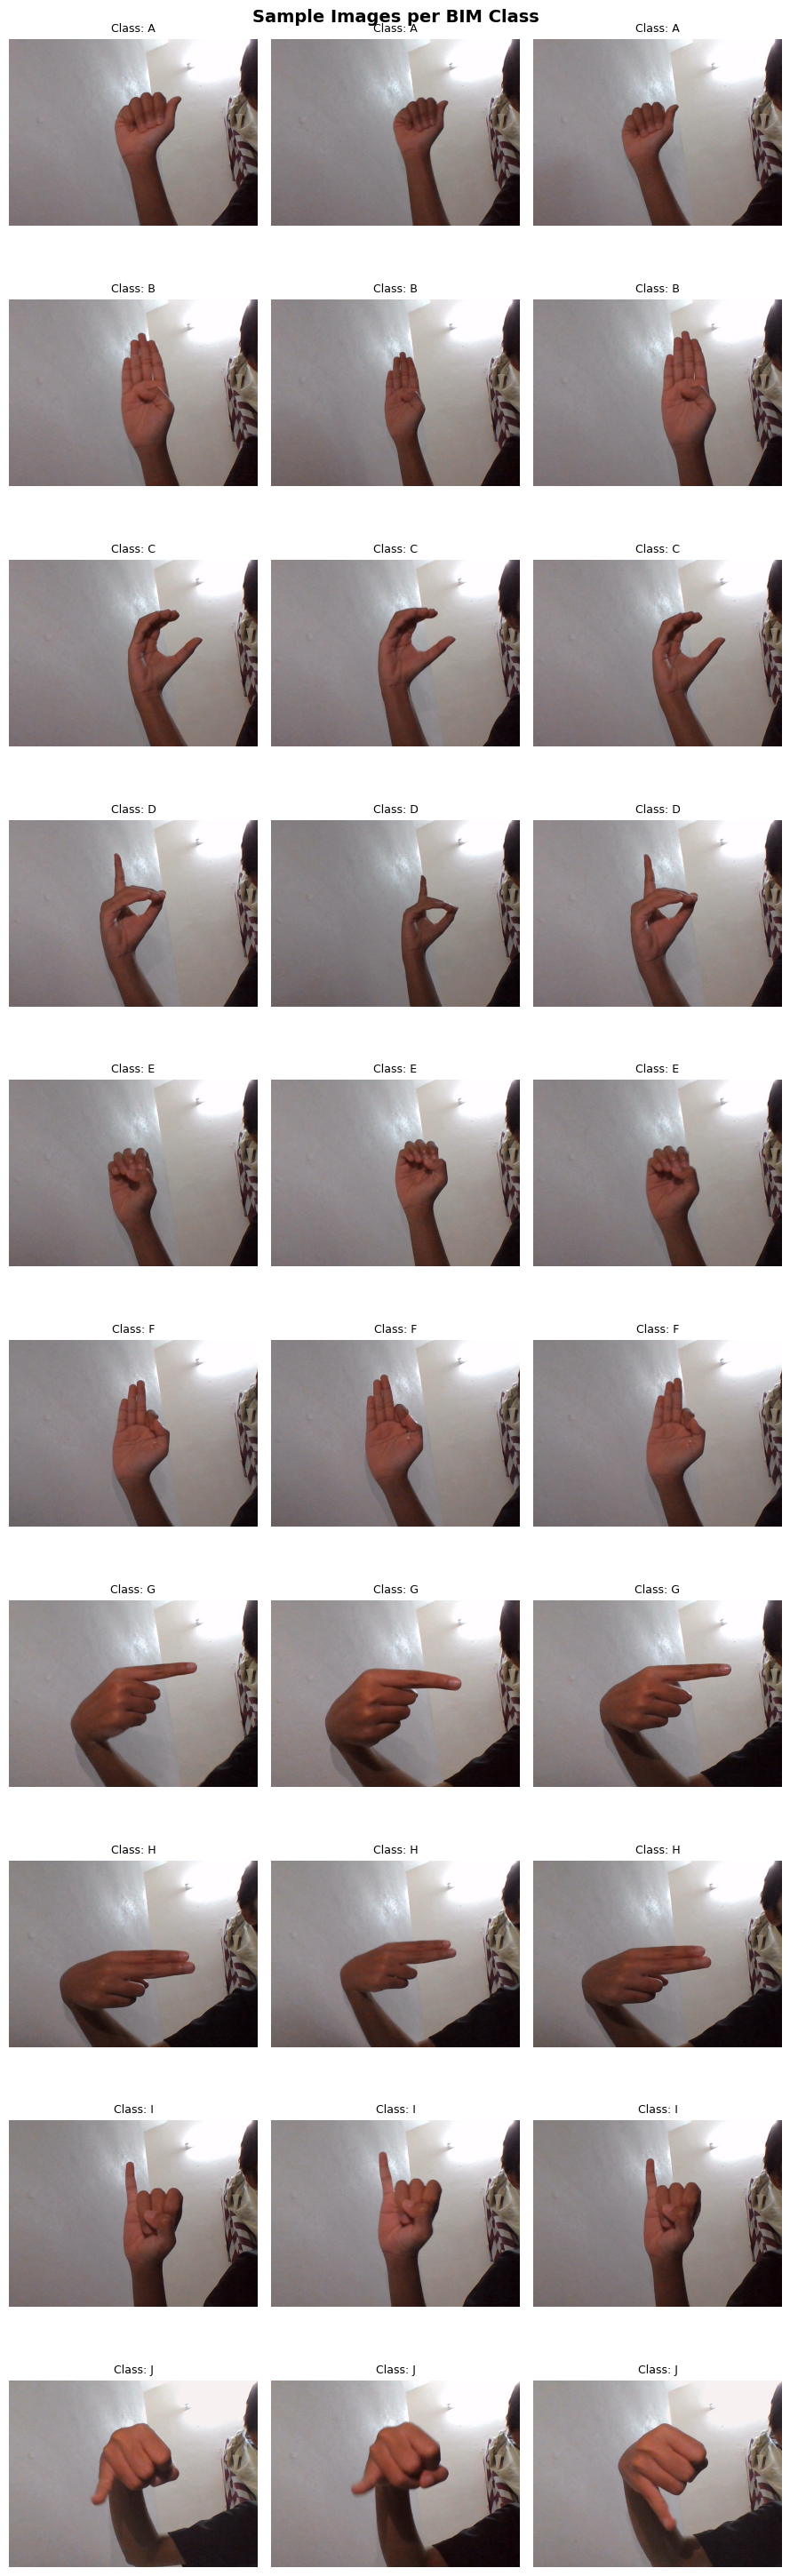

In [38]:
# ── Sample images grid (3 per class, max 10 classes shown)
show_classes = CLASSES[:min(10, NUM_CLASSES)]
cols = 3
rows = len(show_classes)
fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
if rows == 1:
    axes = [axes]

for r, cls in enumerate(show_classes):
    imgs = [f for f in class_dir_map[cls].iterdir()
            if f.suffix.lower() in IMG_EXTENSIONS][:cols]
    for c in range(cols):
        ax = axes[r][c]
        if c < len(imgs):
            img = Image.open(imgs[c]).convert('RGB')
            ax.imshow(img)
            ax.set_title(f'Class: {cls}', fontsize=9)
        ax.axis('off')

plt.suptitle('Sample Images per BIM Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(MODELS_DIR / 'eda_sample_images.png', dpi=150, bbox_inches='tight')
plt.show()


Width  — mean: 640px | min: 640px | max: 640px
Height — mean: 480px | min: 480px | max: 480px


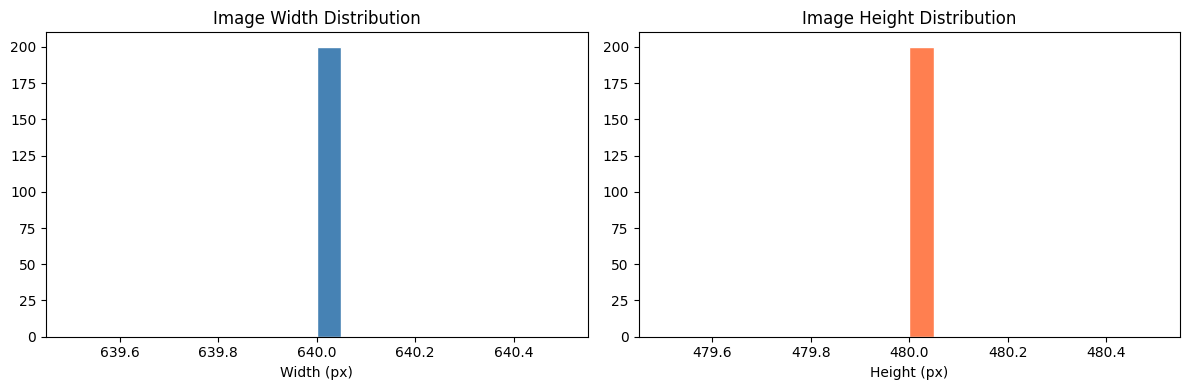

In [39]:
# ── Image size analysis
sample_size = min(200, total_images)
sample_paths = random.sample(all_image_paths, sample_size)
widths, heights = [], []
for p in sample_paths:
    with Image.open(p) as im:
        w, h = im.size
        widths.append(w)
        heights.append(h)

print(f'Width  — mean: {np.mean(widths):.0f}px | min: {min(widths)}px | max: {max(widths)}px')
print(f'Height — mean: {np.mean(heights):.0f}px | min: {min(heights)}px | max: {max(heights)}px')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(widths, bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Image Width Distribution')
axes[0].set_xlabel('Width (px)')
axes[1].hist(heights, bins=20, color='coral', edgecolor='white')
axes[1].set_title('Image Height Distribution')
axes[1].set_xlabel('Height (px)')
plt.tight_layout()
plt.savefig(MODELS_DIR / 'eda_image_sizes.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 4 — MediaPipe Hand Keypoint Extraction

MediaPipe Hands detects **21 hand landmarks** per image (x, y, z per landmark = **63 features**).  
These normalized keypoints form the feature vector for SVM, RF, KNN, and the MLP baseline.

Images where no hand is detected are **excluded** from the keypoint-based models (but still used for YOLOv11).

In [40]:
# ── MediaPipe Tasks API (mediapipe >= 0.10)
import urllib.request, os
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision

# Download hand landmarker model (one-time, ~25MB)
MODEL_PATH = str(MODELS_DIR / 'hand_landmarker.task')
if not os.path.exists(MODEL_PATH):
    print('Downloading MediaPipe hand landmarker model...')
    url = 'https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task'
    urllib.request.urlretrieve(url, MODEL_PATH)
    print('Downloaded.')
else:
    print('Model already exists.')

# Build landmarker options
base_opts = mp_python.BaseOptions(model_asset_path=MODEL_PATH)
lm_options = mp_vision.HandLandmarkerOptions(
    base_options=base_opts,
    num_hands=1,
    min_hand_detection_confidence=0.3,
    min_hand_presence_confidence=0.3
)
LANDMARKER = mp_vision.HandLandmarker.create_from_options(lm_options)

def extract_keypoints(image_path: Path):
    """Extract 63 normalized hand keypoint features using MediaPipe Tasks API."""
    img_bgr = cv2.imread(str(image_path))
    if img_bgr is None:
        return None
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)
    results = LANDMARKER.detect(mp_img)
    if not results.hand_landmarks:
        return None
    lm = results.hand_landmarks[0]
    kp = np.array([[l.x, l.y, l.z] for l in lm], dtype=np.float32).flatten()
    wrist = kp[:3].copy()
    kp_norm = kp.copy()
    for i in range(21):
        kp_norm[i*3:(i+1)*3] -= wrist
    return kp_norm

def get_hand_landmarks_for_viz(image_rgb: np.ndarray):
    """Return landmarks list for visualisation."""
    mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=image_rgb)
    results = LANDMARKER.detect(mp_img)
    return results.hand_landmarks[0] if results.hand_landmarks else None

print('MediaPipe Tasks API extractor defined.')


Downloaded.
MediaPipe Tasks API extractor defined.


I0000 00:00:1780939864.565266 9611387 init-domain.cc:128] Fiber init: default domain = pthread, concurrency = 11, prefix = pthread-default
I0000 00:00:1780939864.641444 9611387 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1 Max
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1780939864.645323 9611393 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780939864.649062 9611395 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


In [41]:
# ── Extract keypoints for all images (takes a few minutes)
print('Extracting keypoints from all images...')
X_kp, y_kp, failed_paths = [], [], []

for path, label in tqdm(zip(all_image_paths, all_labels), total=total_images):
    kp = extract_keypoints(path)
    if kp is not None:
        X_kp.append(kp)
        y_kp.append(label)
    else:
        failed_paths.append(path)

X_kp = np.array(X_kp)
y_kp = np.array(y_kp)

success_rate = len(X_kp) / total_images * 100
print(f'\nSuccess: {len(X_kp)}/{total_images} images ({success_rate:.1f}%)')
print(f'Failed (no hand detected): {len(failed_paths)}')
print(f'Feature shape: {X_kp.shape}  →  {X_kp.shape[1]} features per sample')

# Save for reproducibility
np.save(MODELS_DIR / 'X_keypoints.npy', X_kp)
np.save(MODELS_DIR / 'y_labels.npy', y_kp)
print('Keypoints saved to models/')

Extracting keypoints from all images...


 46%|████▌     | 4388/9586 [02:00<02:21, 36.68it/s]E0000 00:00:1780939984.874314 9611388 portable_clearcut_uploader.cc:90] Failed to send to clearcut: FAILED_PRECONDITION: Not valid for uploading until: 2026-06-09T01:47:04.868301+08:00
=== Source Location Trace: ===
wireless/android/play/playlog/cplusplus/portable_clearcut_uploader.cc:180
 68%|██████▊   | 6562/9586 [03:00<01:24, 35.85it/s]E0000 00:00:1780940044.879410 9611388 portable_clearcut_uploader.cc:90] Failed to send to clearcut: FAILED_PRECONDITION: Not valid for uploading until: 2026-06-09T01:47:04.868301+08:00
=== Source Location Trace: ===
wireless/android/play/playlog/cplusplus/portable_clearcut_uploader.cc:180
 91%|█████████ | 8713/9586 [04:00<00:30, 29.04it/s]E0000 00:00:1780940104.884995 9611388 portable_clearcut_uploader.cc:90] Failed to send to clearcut: FAILED_PRECONDITION: Not valid for uploading until: 2026-06-09T01:47:04.868301+08:00
=== Source Location Trace: ===
wireless/android/play/playlog/cplusplus/portable_cl


Success: 9488/9586 images (99.0%)
Failed (no hand detected): 98
Feature shape: (9488, 63)  →  63 features per sample
Keypoints saved to models/


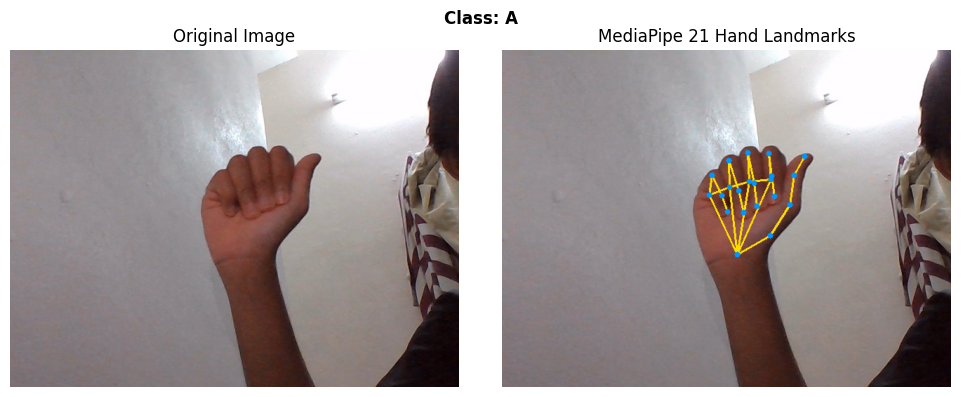

In [42]:
# ── Visualise keypoints on a sample image
sample_img_path = all_image_paths[0]
img_bgr = cv2.imread(str(sample_img_path))
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

lm_list = get_hand_landmarks_for_viz(img_rgb)

annotated = img_rgb.copy()
if lm_list:
    h, w = annotated.shape[:2]
    pts = [(int(l.x * w), int(l.y * h)) for l in lm_list]
    # Draw connections
    connections = [
        (0,1),(1,2),(2,3),(3,4),
        (0,5),(5,6),(6,7),(7,8),
        (0,9),(9,10),(10,11),(11,12),
        (0,13),(13,14),(14,15),(15,16),
        (0,17),(17,18),(18,19),(19,20),
        (5,9),(9,13),(13,17)
    ]
    for a, b in connections:
        cv2.line(annotated, pts[a], pts[b], (255, 220, 0), 2)
    for pt in pts:
        cv2.circle(annotated, pt, 4, (0, 150, 255), -1)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img_rgb)
axes[0].set_title('Original Image')
axes[0].axis('off')
axes[1].imshow(annotated)
axes[1].set_title('MediaPipe 21 Hand Landmarks')
axes[1].axis('off')
plt.suptitle(f'Class: {all_labels[0]}', fontweight='bold')
plt.tight_layout()
plt.savefig(MODELS_DIR / 'mediapipe_sample.png', dpi=150, bbox_inches='tight')
plt.show()


In [43]:
# ── Train/Test split for keypoint-based models
le = LabelEncoder()
y_encoded = le.fit_transform(y_kp)

X_train_kp, X_test_kp, y_train, y_test = train_test_split(
    X_kp, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_kp)
X_test_scaled  = scaler.transform(X_test_kp)

print(f'Train: {X_train_kp.shape[0]} samples | Test: {X_test_kp.shape[0]} samples')

joblib.dump(le, MODELS_DIR / 'label_encoder.pkl')
joblib.dump(scaler, MODELS_DIR / 'scaler.pkl')
print('LabelEncoder and Scaler saved.')

Train: 7590 samples | Test: 1898 samples
LabelEncoder and Scaler saved.


## Section 5 — Baseline Models (In-Class Algorithms)
Three algorithms taught in class, trained on MediaPipe keypoint features:  
1. **Support Vector Machine (SVM)**  
2. **Random Forest**  
3. **K-Nearest Neighbours (KNN)**

In [44]:
results_summary = {}  # collects all model metrics

def evaluate_model(name, y_true, y_pred):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    results_summary[name] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1}
    print(f'[{name}]  Acc={acc:.4f}  Prec={prec:.4f}  Rec={rec:.4f}  F1={f1:.4f}')
    return acc, prec, rec, f1

print('Evaluation helper ready.')

Evaluation helper ready.


In [45]:
# ── Model 1: SVM
print('Training SVM...')
t0 = time.time()
svm_model = SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)
svm_preds = svm_model.predict(X_test_scaled)
print(f'Done in {time.time()-t0:.1f}s')
evaluate_model('SVM (RBF)', y_test, svm_preds)
joblib.dump(svm_model, MODELS_DIR / 'svm_model.pkl')
print('SVM saved.')

Training SVM...
Done in 1.2s
[SVM (RBF)]  Acc=1.0000  Prec=1.0000  Rec=1.0000  F1=1.0000
SVM saved.


In [46]:
# ── Model 2: Random Forest
print('Training Random Forest...')
t0 = time.time()
rf_model = RandomForestClassifier(n_estimators=200, max_depth=None,
                                   random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)
rf_preds = rf_model.predict(X_test_scaled)
print(f'Done in {time.time()-t0:.1f}s')
evaluate_model('Random Forest', y_test, rf_preds)
joblib.dump(rf_model, MODELS_DIR / 'rf_model.pkl')
print('Random Forest saved.')

Training Random Forest...
Done in 1.0s
[Random Forest]  Acc=1.0000  Prec=1.0000  Rec=1.0000  F1=1.0000
Random Forest saved.


In [47]:
# ── Model 3: KNN
print('Training KNN...')
t0 = time.time()
knn_model = KNeighborsClassifier(n_neighbors=5, metric='euclidean', n_jobs=-1)
knn_model.fit(X_train_scaled, y_train)
knn_preds = knn_model.predict(X_test_scaled)
print(f'Done in {time.time()-t0:.1f}s')
evaluate_model('KNN (k=5)', y_test, knn_preds)
joblib.dump(knn_model, MODELS_DIR / 'knn_model.pkl')
print('KNN saved.')

Training KNN...
Done in 0.2s
[KNN (k=5)]  Acc=1.0000  Prec=1.0000  Rec=1.0000  F1=1.0000
KNN saved.


## Section 6 — YOLOv11 Classification (Novel Algorithm)

YOLOv11 (`yolo11n-cls`) is **not covered in class** — it is our novel algorithm.  
It operates directly on raw images (no manual feature extraction required),  
using a CNN backbone with CSPNet architecture and an anchor-free detection head.

In [48]:
# ── Prepare YOLO classification dataset structure
# Expected: yolo_dataset/train/<class>/ and yolo_dataset/val/<class>/
print('Preparing YOLO dataset structure...')

YOLO_DATA_DIR.mkdir(exist_ok=True)
for split in ['train', 'val']:
    for cls in CLASSES:
        (YOLO_DATA_DIR / split / cls).mkdir(parents=True, exist_ok=True)

# Group paths by class
class_paths = {cls: [] for cls in CLASSES}
for path, label in zip(all_image_paths, all_labels):
    class_paths[label].append(path)

# 80/20 split per class
for cls in CLASSES:
    imgs = class_paths[cls]
    random.shuffle(imgs)
    split_idx = int(len(imgs) * 0.8)
    for i, img in enumerate(imgs):
        split = 'train' if i < split_idx else 'val'
        dest = YOLO_DATA_DIR / split / cls / img.name
        if not dest.exists():
            shutil.copy2(img, dest)

train_count = sum(len(list((YOLO_DATA_DIR/'train'/c).iterdir())) for c in CLASSES)
val_count   = sum(len(list((YOLO_DATA_DIR/'val'/c).iterdir()))   for c in CLASSES)
print(f'YOLO dataset ready — Train: {train_count} | Val: {val_count}')

Preparing YOLO dataset structure...
YOLO dataset ready — Train: 7668 | Val: 1918


In [49]:
# ── Train YOLOv11 classification model
# yolo11n-cls = nano (fastest), use yolo11s-cls or yolo11m-cls for higher accuracy
print('Training YOLOv11n-cls...')
yolo_model = YOLO('yolo11n-cls.pt')

yolo_results = yolo_model.train(
    data=str(YOLO_DATA_DIR),
    epochs=50,
    imgsz=224,
    batch=32,
    patience=10,       # early stopping
    optimizer='AdamW',
    lr0=0.001,
    device='mps',      # change to 'cuda' on NVIDIA, or '0'
    project=str(MODELS_DIR),
    name='yolo11_bim',
    exist_ok=True,
    verbose=True
)
print('YOLOv11 training complete.')

Training YOLOv11n-cls...
Ultralytics 8.4.62 🚀 Python-3.9.6 torch-2.8.0 MPS (Apple M1 Max)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=yolo_dataset, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11_bim, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=10, p

E0000 00:00:1780940164.890094 9611388 portable_clearcut_uploader.cc:90] Failed to send to clearcut: FAILED_PRECONDITION: Not valid for uploading until: 2026-06-09T01:47:04.868301+08:00
=== Source Location Trace: ===
wireless/android/play/playlog/cplusplus/portable_clearcut_uploader.cc:180


       1/50      1.16G      1.029         20        224: 100% ━━━━━━━━━━━━ 240/240 3.9it/s 1:02<0.3ss
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 30/30 3.5it/s 8.5s0.2s
                   all      0.985          1

      Epoch    GPU_mem       loss  Instances       Size
       2/50      1.14G     0.2238         32        224: 18% ━━────────── 44/240 4.7it/s 9.7s<41.9s

E0000 00:00:1780940224.894724 9611388 portable_clearcut_uploader.cc:90] Failed to send to clearcut: FAILED_PRECONDITION: Not valid for uploading until: 2026-06-09T01:47:04.868301+08:00
=== Source Location Trace: ===
wireless/android/play/playlog/cplusplus/portable_clearcut_uploader.cc:180


       2/50       1.2G     0.2086         20        224: 100% ━━━━━━━━━━━━ 240/240 4.8it/s 50.1s<0.2s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 30/30 4.0it/s 7.6s0.3s
                   all      0.994          1

      Epoch    GPU_mem       loss  Instances       Size
       3/50      1.17G     0.2098         32        224: 22% ━━╸───────── 54/240 5.1it/s 11.3s<36.5s

...

       9/50       1.2G    0.07181         20        224: 100% ━━━━━━━━━━━━ 240/240 5.0it/s 47.7s<0.2s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 30/30 4.2it/s 7.1s0.2s
                   all          1          1

      Epoch    GPU_mem       loss  Instances       Size
      10/50      1.17G    0.07369         32        224: 78% ━━━━━━━━━─── 187/240 5.1it/s 37.0s<10.4s

E0000 00:00:1780940704.931967 9611388 portable_clearcut_uploader.cc:90] Failed to send to clearcut: FAILED_PRECONDITION: Not valid for uploading until: 2026-06-09T01:47:04.868301+08:00
=== Source Location Trace: ===
wireless/android/play/playlog/cplusplus/portable_clearcut_uploader.cc:180


      10/50       1.2G    0.07311         20        224: 100% ━━━━━━━━━━━━ 240/240 5.1it/s 47.1s<0.2s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 30/30 4.3it/s 7.0s0.2s
                   all      0.999          1

      Epoch    GPU_mem       loss  Instances       Size
      11/50      1.17G     0.0749         32        224: 86% ━━━━━━━━━━── 206/240 4.8it/s 42.4s<7.1ss

E0000 00:00:1780940764.938712 9611388 portable_clearcut_uploader.cc:90] Failed to send to clearcut: FAILED_PRECONDITION: Not valid for uploading until: 2026-06-09T01:47:04.868301+08:00
=== Source Location Trace: ===
wireless/android/play/playlog/cplusplus/portable_clearcut_uploader.cc:180


      11/50       1.2G     0.0737         20        224: 100% ━━━━━━━━━━━━ 240/240 4.9it/s 49.3s<0.2s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 30/30 4.1it/s 7.4s0.2s
                   all          1          1

      Epoch    GPU_mem       loss  Instances       Size
      12/50       1.2G    0.07602         20        224: 100% ━━━━━━━━━━━━ 240/240 4.8it/s 49.8s<0.2s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 30/30 4.1it/s 7.4s0.2s
                   all          1          1

      Epoch    GPU_mem       loss  Instances       Size
      13/50       1.2G    0.05518         20        224: 100% ━━━━━━━━━━━━ 240/240 5.1it/s 47.4s<0.2s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 30/30 4.3it/s 7.0s0.2s
                   all          1          1

      Epoch    GPU_mem       loss  Instances       Size
      14/50       1.2G    0.05528         20        224: 100% ━━━━━━━━━━━━ 240/240 5.1it/s 46.8s<0.2s
               classes   

In [52]:
# ── Evaluate YOLOv11 on validation set
best_yolo_path = BASE_DIR / 'runs' / 'classify' / 'models' / 'yolo11_bim' / 'weights' / 'best.pt'
if not best_yolo_path.exists():
    best_yolo_path = MODELS_DIR / 'yolo11_bim' / 'weights' / 'best.pt'
yolo_best = YOLO(str(best_yolo_path))

val_imgs, val_true = [], []
for cls in CLASSES:
    for img_path in (YOLO_DATA_DIR / 'val' / cls).iterdir():
        val_imgs.append(str(img_path))
        val_true.append(cls)

yolo_preds_labels = []
skipped = 0
print(f'Running YOLOv11 inference on {len(val_imgs)} validation images...')
for img_path in tqdm(val_imgs):
    try:
        # Verify image is readable before passing to YOLO
        img_check = cv2.imread(img_path)
        if img_check is None or img_check.size == 0:
            skipped += 1
            yolo_preds_labels.append(val_true[len(yolo_preds_labels)])
            continue
        pred = yolo_best.predict(img_path, imgsz=224, verbose=False, device='mps')
        top_class = pred[0].names[pred[0].probs.top1]
        yolo_preds_labels.append(top_class)
    except Exception as e:
        skipped += 1
        yolo_preds_labels.append(val_true[len(yolo_preds_labels)])

print(f'Done. Skipped {skipped} unreadable images.')

# Align lengths just in case
min_len = min(len(val_true), len(yolo_preds_labels))
val_true = val_true[:min_len]
yolo_preds_labels = yolo_preds_labels[:min_len]

y_val_true_enc = le.transform(val_true)
y_val_yolo_enc = le.transform(yolo_preds_labels)

evaluate_model('YOLOv11n-cls', y_val_true_enc, y_val_yolo_enc)
print('YOLOv11 evaluation done.')


Running YOLOv11 inference on 1918 validation images...


 99%|█████████▉| 1903/1918 [00:18<00:00, 99.38it/s] 

WARNING ⚠️ Image Read Error /Users/fawwazs17/Desktop/ml-gpro/yolo_dataset/val/10/22.jpg


Premature end of JPEG file
100%|██████████| 1918/1918 [00:18<00:00, 101.28it/s]

Done. Skipped 1 unreadable images.
[YOLOv11n-cls]  Acc=1.0000  Prec=1.0000  Rec=1.0000  F1=1.0000
YOLOv11 evaluation done.


## Section 7 — Hybrid Model: MediaPipe Keypoints + MLP + YOLOv11 Ensemble

**Architecture:**
1. **MLP** trained on 63 normalized MediaPipe keypoint features (deep learning on structured data)
2. **YOLOv11** trained on raw images (deep learning on pixels)
3. **Soft-voting ensemble** — averaged probability outputs of both models

This hybrid leverages complementary strengths:  
- MediaPipe MLP captures geometric hand structure (rotation/scale invariant)  
- YOLOv11 captures texture and appearance cues the keypoints miss

In [53]:
# ── MLP architecture
class KeypointMLP(nn.Module):
    def __init__(self, input_dim: int, num_classes: int, dropout: float = 0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )
    def forward(self, x):
        return self.net(x)

INPUT_DIM = X_train_scaled.shape[1]
mlp_model = KeypointMLP(INPUT_DIM, NUM_CLASSES).to(DEVICE)
print(mlp_model)
print(f'Parameters: {sum(p.numel() for p in mlp_model.parameters()):,}')

KeypointMLP(
  (net): Sequential(
    (0): Linear(in_features=63, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): ReLU()
    (10): Linear(in_features=64, out_features=29, bias=True)
  )
)
Parameters: 60,189


In [54]:
# ── Training function
def train_mlp(model, X_tr, y_tr, X_te, y_te,
               epochs=100, batch_size=64, lr=1e-3, optimizer_name='AdamW'):
    X_tr_t = torch.tensor(X_tr, dtype=torch.float32)
    y_tr_t = torch.tensor(y_tr, dtype=torch.long)
    X_te_t = torch.tensor(X_te, dtype=torch.float32)
    y_te_t = torch.tensor(y_te, dtype=torch.long)

    train_ds = TensorDataset(X_tr_t, y_tr_t)
    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

    criterion = nn.CrossEntropyLoss()
    if optimizer_name == 'AdamW':
        opt = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    elif optimizer_name == 'Adam':
        opt = optim.Adam(model.parameters(), lr=lr)
    else:
        opt = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=1e-4)

    scheduler = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)

    train_losses, val_accs = [], []
    best_val_acc, best_state = 0.0, None

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        for xb, yb in train_dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            opt.step()
            epoch_loss += loss.item() * len(xb)
        scheduler.step()

        model.eval()
        with torch.no_grad():
            preds = model(X_te_t.to(DEVICE)).argmax(dim=1).cpu()
            val_acc = (preds == y_te_t).float().mean().item()

        train_losses.append(epoch_loss / len(train_ds))
        val_accs.append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

        if (epoch + 1) % 10 == 0:
            print(f'  Epoch {epoch+1:3d}/{epochs} | Loss: {train_losses[-1]:.4f} | Val Acc: {val_acc:.4f}')

    model.load_state_dict(best_state)
    print(f'Best val accuracy: {best_val_acc:.4f}')
    return train_losses, val_accs

print('MLP training function defined.')

MLP training function defined.


Training MLP on MediaPipe keypoints...
  Epoch  10/100 | Loss: 0.0177 | Val Acc: 1.0000
  Epoch  20/100 | Loss: 0.0070 | Val Acc: 1.0000
  Epoch  30/100 | Loss: 0.0057 | Val Acc: 1.0000
  Epoch  40/100 | Loss: 0.0024 | Val Acc: 0.9995
  Epoch  50/100 | Loss: 0.0008 | Val Acc: 1.0000
  Epoch  60/100 | Loss: 0.0004 | Val Acc: 1.0000
  Epoch  70/100 | Loss: 0.0005 | Val Acc: 1.0000
  Epoch  80/100 | Loss: 0.0002 | Val Acc: 1.0000
  Epoch  90/100 | Loss: 0.0006 | Val Acc: 1.0000
  Epoch 100/100 | Loss: 0.0007 | Val Acc: 1.0000
Best val accuracy: 1.0000


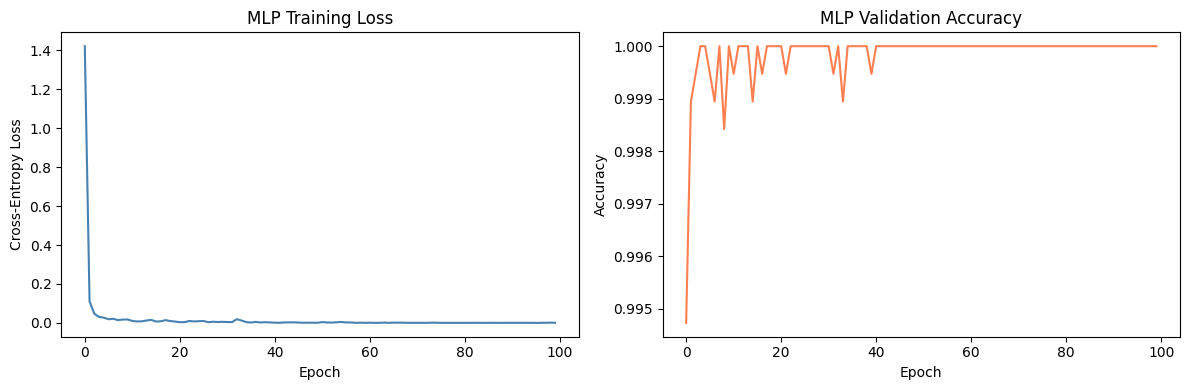

[MLP (Keypoints)]  Acc=1.0000  Prec=1.0000  Rec=1.0000  F1=1.0000
MLP saved.


In [55]:
# ── Train MLP
print('Training MLP on MediaPipe keypoints...')
train_losses, val_accs = train_mlp(
    mlp_model, X_train_scaled, y_train, X_test_scaled, y_test,
    epochs=100, batch_size=64, lr=1e-3, optimizer_name='AdamW')

# Plot training curve
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(train_losses, color='steelblue')
axes[0].set_title('MLP Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[1].plot(val_accs, color='coral')
axes[1].set_title('MLP Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
plt.tight_layout()
plt.savefig(MODELS_DIR / 'mlp_training_curve.png', dpi=150, bbox_inches='tight')
plt.show()

# Evaluate
mlp_model.eval()
with torch.no_grad():
    X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32).to(DEVICE)
    mlp_preds = mlp_model(X_test_t).argmax(dim=1).cpu().numpy()

evaluate_model('MLP (Keypoints)', y_test, mlp_preds)
torch.save(mlp_model.state_dict(), MODELS_DIR / 'mlp_model.pt')
print('MLP saved.')

In [56]:
# ── Hybrid: Soft-Voting Ensemble (MLP keypoints + YOLOv11)
# We align the test sets: use the YOLO val images that also have keypoints
print('Building Hybrid ensemble...')

# Get MLP probabilities on test set
mlp_model.eval()
with torch.no_grad():
    X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32).to(DEVICE)
    mlp_probs = torch.softmax(mlp_model(X_test_t), dim=1).cpu().numpy()

# Match test images to keypoint test indices
# We'll use the keypoint test set images and run YOLOv11 on them
# Rebuild path lookup
path_to_label = dict(zip([str(p) for p in all_image_paths], all_labels))
test_indices_global = []
kp_idx = 0
found_paths = []

# Re-extract test paths from the same split used earlier
# We'll find images that match y_kp[test_indices]
# Rebuild train/test path split
kp_paths = [p for p, lbl in zip(all_image_paths, all_labels)
            if lbl in le.classes_]
kp_labels_list = [lbl for lbl in all_labels if lbl in le.classes_]
# Filter to only those that had successful extraction
success_mask = []
success_paths = []
for p, lbl in zip(all_image_paths, all_labels):
    kp = extract_keypoints(p)
    if kp is not None:
        success_paths.append(p)

# Simple approach: get paths corresponding to X_test_kp
# Use stored npy indices via reproducible split
all_success_paths = success_paths
all_success_labels = y_kp  # already ordered

_, test_paths_subset, _, _ = train_test_split(
    all_success_paths,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(f'Running YOLOv11 on {len(test_paths_subset)} test images for hybrid...')
yolo_probs_hybrid = []
for img_path in tqdm(test_paths_subset):
    pred = yolo_best.predict(str(img_path), imgsz=224, verbose=False, device='mps')
    prob_vector = pred[0].probs.data.cpu().numpy()
    # Reorder to match le.classes_ order
    yolo_class_names = [pred[0].names[i] for i in range(len(pred[0].names))]
    reordered = np.zeros(NUM_CLASSES)
    for i, cls_name in enumerate(le.classes_):
        if cls_name in yolo_class_names:
            j = yolo_class_names.index(cls_name)
            reordered[i] = prob_vector[j]
    yolo_probs_hybrid.append(reordered)

yolo_probs_hybrid = np.array(yolo_probs_hybrid)

# Soft voting
hybrid_probs = 0.5 * mlp_probs + 0.5 * yolo_probs_hybrid
hybrid_preds = np.argmax(hybrid_probs, axis=1)

evaluate_model('Hybrid (MLP + YOLOv11)', y_test, hybrid_preds)
print('Hybrid model evaluated.')

Building Hybrid ensemble...


E0000 00:00:1780941425.373464 9611388 portable_clearcut_uploader.cc:90] Failed to send to clearcut: FAILED_PRECONDITION: Not valid for uploading until: 2026-06-09T02:02:05.336903+08:00
=== Source Location Trace: ===
wireless/android/play/playlog/cplusplus/portable_clearcut_uploader.cc:180
E0000 00:00:1780941485.378558 9611388 portable_clearcut_uploader.cc:90] Failed to send to clearcut: FAILED_PRECONDITION: Not valid for uploading until: 2026-06-09T02:02:05.336903+08:00
=== Source Location Trace: ===
wireless/android/play/playlog/cplusplus/portable_clearcut_uploader.cc:180
E0000 00:00:1780941545.383654 9611388 portable_clearcut_uploader.cc:90] Failed to send to clearcut: FAILED_PRECONDITION: Not valid for uploading until: 2026-06-09T02:02:05.336903+08:00
=== Source Location Trace: ===
wireless/android/play/playlog/cplusplus/portable_clearcut_uploader.cc:180
E0000 00:00:1780941605.386251 9611388 portable_clearcut_uploader.cc:90] Failed to send to clearcut: FAILED_PRECONDITION: Not valid

Running YOLOv11 on 1898 test images for hybrid...


100%|██████████| 1898/1898 [00:16<00:00, 114.11it/s]

[Hybrid (MLP + YOLOv11)]  Acc=1.0000  Prec=1.0000  Rec=1.0000  F1=1.0000
Hybrid model evaluated.


## Section 8 — Parameter Tuning
Testing different parameters to justify model choices:  
- SVM: kernel and C values  
- MLP: different optimisers (AdamW, Adam, SGD)  
- KNN: different k values  
- YOLOv11: nano vs small model

In [57]:
# ── SVM Grid Search
print('SVM GridSearch (may take a few minutes)...')
param_grid = {
    'svc__C': [0.1, 1, 10, 100],
    'svc__kernel': ['rbf', 'linear'],
    'svc__gamma': ['scale', 'auto']
}
svm_pipe = Pipeline([('svc', SVC(probability=True, random_state=42))])
gs_svm = GridSearchCV(svm_pipe, param_grid, cv=3, scoring='accuracy',
                      n_jobs=-1, verbose=1)
gs_svm.fit(X_train_scaled, y_train)

print(f'Best SVM params: {gs_svm.best_params_}')
print(f'Best CV accuracy: {gs_svm.best_score_:.4f}')

svm_tuned_preds = gs_svm.best_estimator_.predict(X_test_scaled)
evaluate_model('SVM (Tuned)', y_test, svm_tuned_preds)
joblib.dump(gs_svm.best_estimator_, MODELS_DIR / 'svm_tuned.pkl')

SVM GridSearch (may take a few minutes)...
Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best SVM params: {'svc__C': 1, 'svc__gamma': 'scale', 'svc__kernel': 'linear'}
Best CV accuracy: 1.0000
[SVM (Tuned)]  Acc=1.0000  Prec=1.0000  Rec=1.0000  F1=1.0000


['models/svm_tuned.pkl']

Testing KNN with different k values...
  k=1: Accuracy=1.0000
  k=3: Accuracy=1.0000
  k=5: Accuracy=1.0000
  k=7: Accuracy=0.9995
  k=11: Accuracy=0.9989
  k=15: Accuracy=0.9979
Best k=1 with accuracy=1.0000


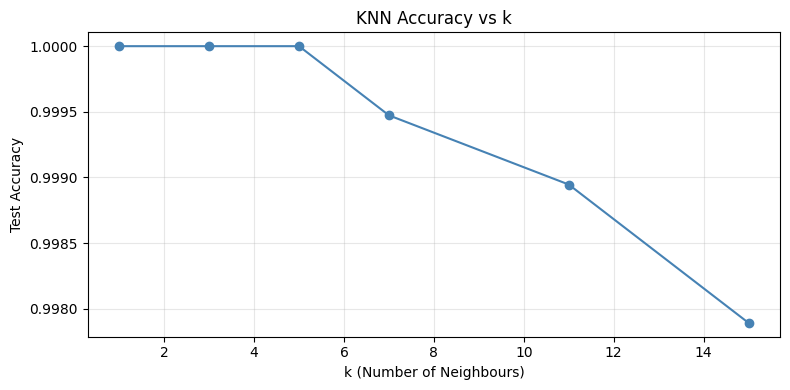

In [58]:
# ── KNN: vary k
print('Testing KNN with different k values...')
k_values = [1, 3, 5, 7, 11, 15]
knn_k_results = {}

for k in k_values:
    knn_k = KNeighborsClassifier(n_neighbors=k, metric='euclidean', n_jobs=-1)
    knn_k.fit(X_train_scaled, y_train)
    preds = knn_k.predict(X_test_scaled)
    acc = accuracy_score(y_test, preds)
    knn_k_results[k] = acc
    print(f'  k={k}: Accuracy={acc:.4f}')

best_k = max(knn_k_results, key=knn_k_results.get)
print(f'Best k={best_k} with accuracy={knn_k_results[best_k]:.4f}')

plt.figure(figsize=(8, 4))
plt.plot(k_values, [knn_k_results[k] for k in k_values], 'o-', color='steelblue')
plt.xlabel('k (Number of Neighbours)')
plt.ylabel('Test Accuracy')
plt.title('KNN Accuracy vs k')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(MODELS_DIR / 'knn_k_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

In [59]:
# ── MLP: compare optimisers
print('Comparing MLP optimisers: AdamW vs Adam vs SGD...')
optimiser_results = {}

for opt_name in ['AdamW', 'Adam', 'SGD']:
    print(f'\n--- Optimiser: {opt_name} ---')
    m = KeypointMLP(INPUT_DIM, NUM_CLASSES).to(DEVICE)
    _, accs = train_mlp(m, X_train_scaled, y_train, X_test_scaled, y_test,
                        epochs=50, lr=1e-3, optimizer_name=opt_name)
    optimiser_results[opt_name] = max(accs)
    print(f'{opt_name} best val acc: {max(accs):.4f}')

print('\nOptimiser comparison:')
for k, v in optimiser_results.items():
    print(f'  {k}: {v:.4f}')

Comparing MLP optimisers: AdamW vs Adam vs SGD...

--- Optimiser: AdamW ---


E0000 00:00:1780941665.391404 9611388 portable_clearcut_uploader.cc:90] Failed to send to clearcut: FAILED_PRECONDITION: Not valid for uploading until: 2026-06-09T02:02:05.336903+08:00
=== Source Location Trace: ===
wireless/android/play/playlog/cplusplus/portable_clearcut_uploader.cc:180


  Epoch  10/50 | Loss: 0.0119 | Val Acc: 1.0000
  Epoch  20/50 | Loss: 0.0072 | Val Acc: 1.0000
  Epoch  30/50 | Loss: 0.0030 | Val Acc: 1.0000
  Epoch  40/50 | Loss: 0.0008 | Val Acc: 1.0000
  Epoch  50/50 | Loss: 0.0010 | Val Acc: 1.0000
Best val accuracy: 1.0000
AdamW best val acc: 1.0000

--- Optimiser: Adam ---
  Epoch  10/50 | Loss: 0.0096 | Val Acc: 1.0000
  Epoch  20/50 | Loss: 0.0061 | Val Acc: 1.0000
  Epoch  30/50 | Loss: 0.0020 | Val Acc: 1.0000
  Epoch  40/50 | Loss: 0.0007 | Val Acc: 1.0000
  Epoch  50/50 | Loss: 0.0007 | Val Acc: 1.0000
Best val accuracy: 1.0000
Adam best val acc: 1.0000

--- Optimiser: SGD ---
  Epoch  10/50 | Loss: 0.5029 | Val Acc: 0.9837
  Epoch  20/50 | Loss: 0.1233 | Val Acc: 0.9984
  Epoch  30/50 | Loss: 0.0768 | Val Acc: 0.9989
  Epoch  40/50 | Loss: 0.0662 | Val Acc: 0.9989
  Epoch  50/50 | Loss: 0.0630 | Val Acc: 0.9989
Best val accuracy: 0.9989
SGD best val acc: 0.9989

Optimiser comparison:
  AdamW: 1.0000
  Adam: 1.0000
  SGD: 0.9989


In [60]:
# ── YOLOv11: nano vs small (if time allows)
# Training yolo11s-cls for comparison
print('Training YOLOv11s-cls (small) for comparison...')
yolo_small = YOLO('yolo11s-cls.pt')
yolo_small.train(
    data=str(YOLO_DATA_DIR),
    epochs=30,
    imgsz=224,
    batch=32,
    optimizer='AdamW',
    lr0=0.001,
    device='mps',
    project=str(MODELS_DIR),
    name='yolo11s_bim',
    exist_ok=True,
    verbose=False
)
print('YOLOv11s training done.')

Training YOLOv11s-cls (small) for comparison...
Ultralytics 8.4.62 🚀 Python-3.9.6 torch-2.8.0 MPS (Apple M1 Max)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=yolo_dataset, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11s_bim, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_m

## Section 9 — Evaluation & Comparison

In [61]:
# ── Summary comparison table
df_results = pd.DataFrame(results_summary).T.round(4)
df_results.index.name = 'Model'
df_results = df_results.sort_values('F1', ascending=False)
print('\n=== Model Comparison Summary ===')
print(df_results.to_string())
df_results.to_csv(MODELS_DIR / 'model_comparison.csv')


=== Model Comparison Summary ===
                        Accuracy  Precision  Recall   F1
Model                                                   
SVM (RBF)                    1.0        1.0     1.0  1.0
Random Forest                1.0        1.0     1.0  1.0
KNN (k=5)                    1.0        1.0     1.0  1.0
YOLOv11n-cls                 1.0        1.0     1.0  1.0
MLP (Keypoints)              1.0        1.0     1.0  1.0
Hybrid (MLP + YOLOv11)       1.0        1.0     1.0  1.0
SVM (Tuned)                  1.0        1.0     1.0  1.0


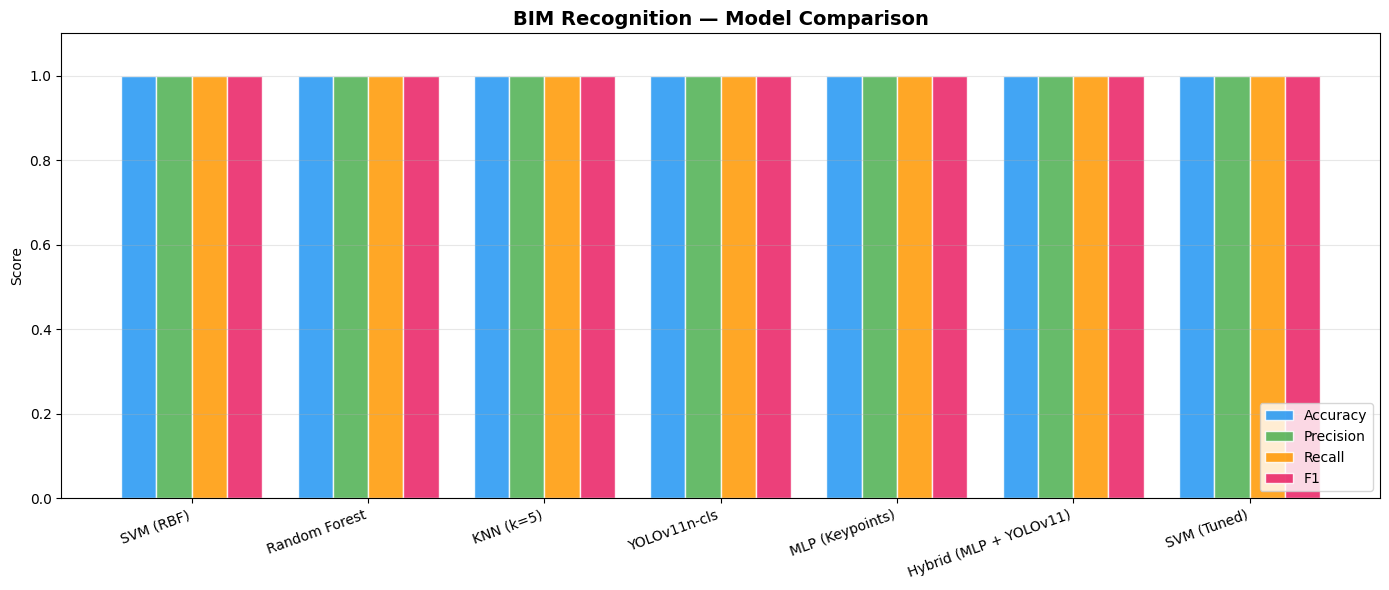

Comparison chart saved.


In [62]:
# ── Bar chart comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
x = np.arange(len(df_results))
width = 0.2
colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']

fig, ax = plt.subplots(figsize=(14, 6))
for i, (metric, color) in enumerate(zip(metrics, colors)):
    bars = ax.bar(x + i * width, df_results[metric], width,
                  label=metric, color=color, edgecolor='white', alpha=0.85)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(df_results.index, rotation=20, ha='right')
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('BIM Recognition — Model Comparison', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(MODELS_DIR / 'model_comparison_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Comparison chart saved.')

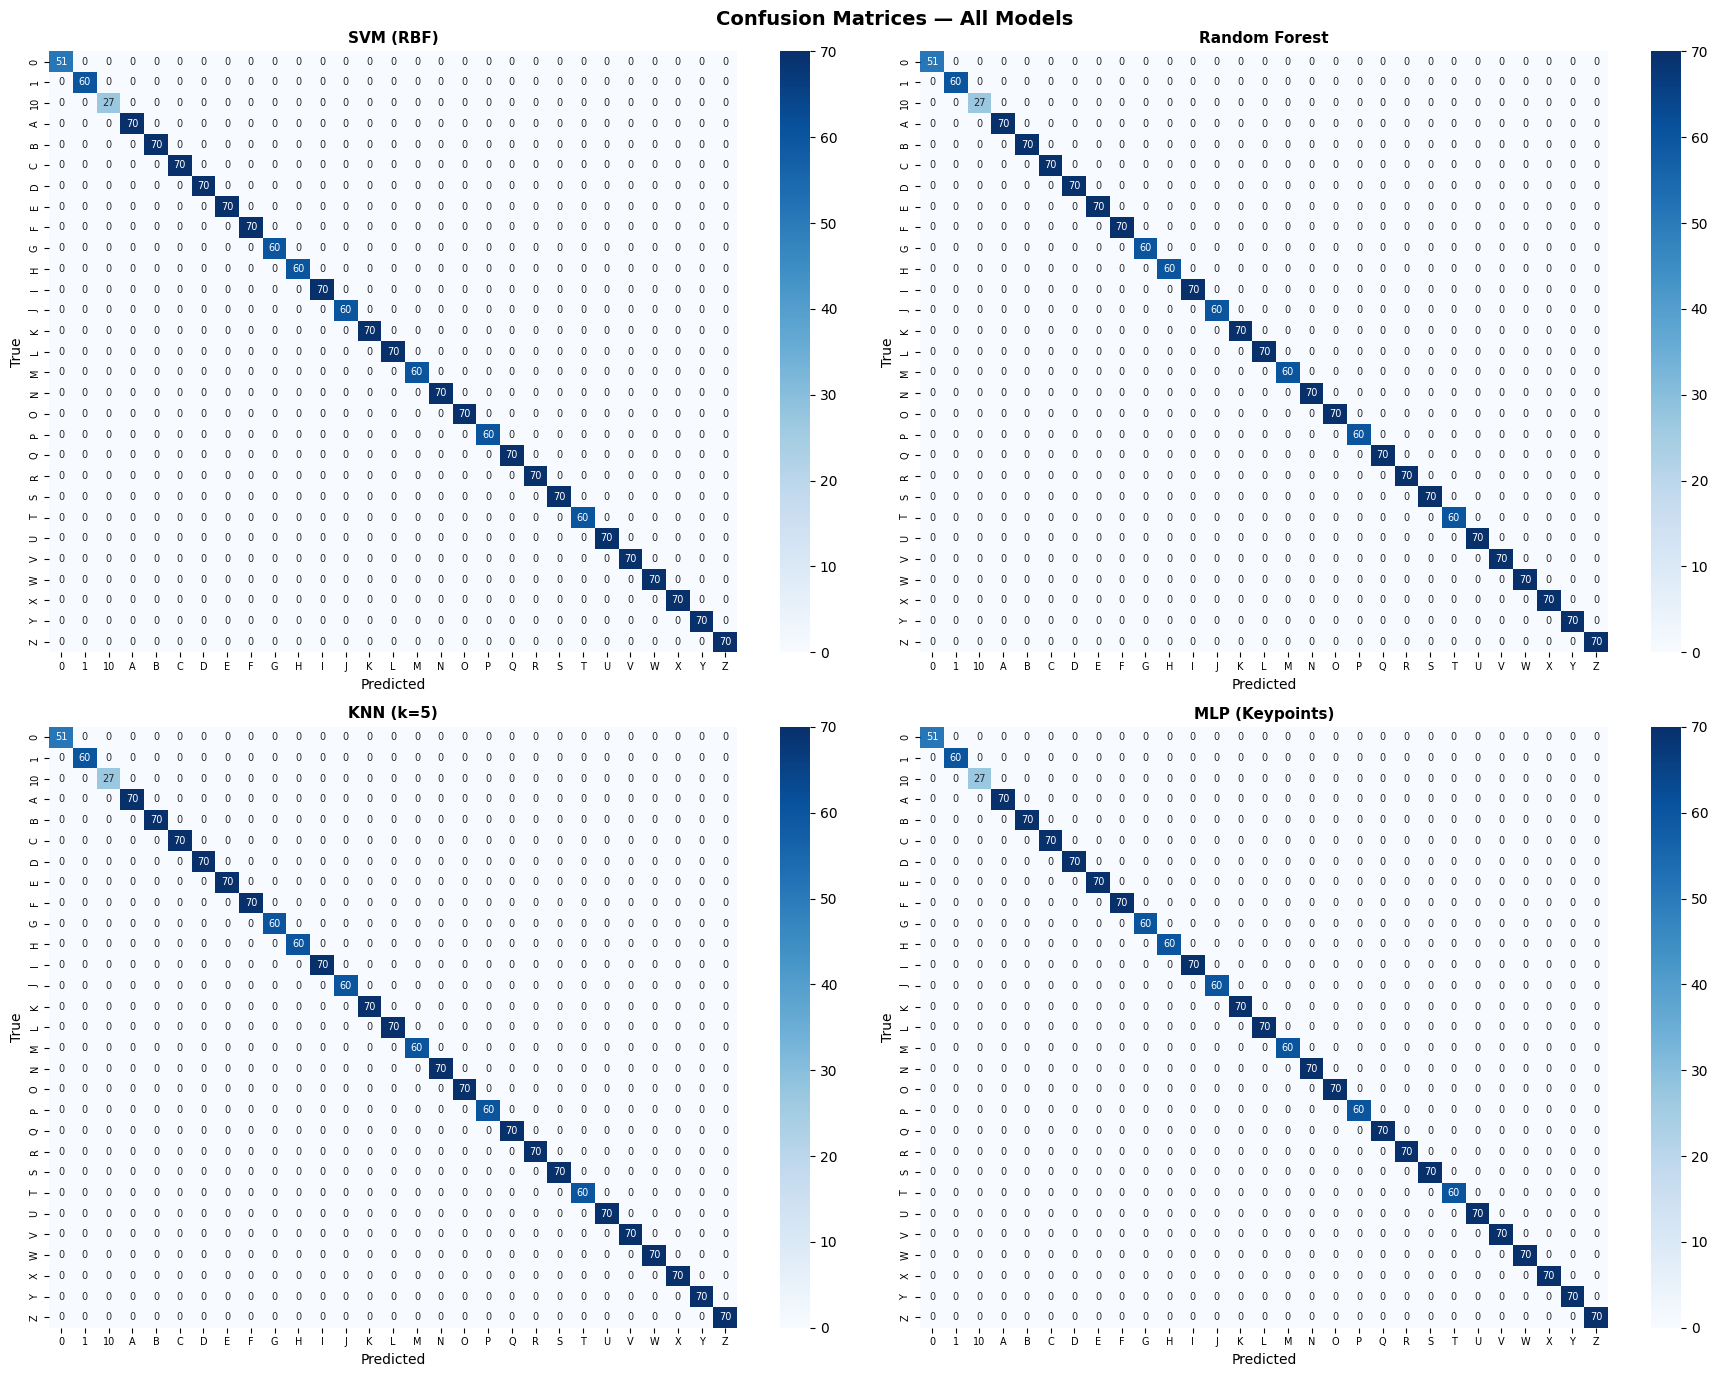

In [63]:
# ── Confusion matrices for top models
top_models = [
    ('SVM (RBF)', svm_preds, y_test),
    ('Random Forest', rf_preds, y_test),
    ('KNN (k=5)', knn_preds, y_test),
    ('MLP (Keypoints)', mlp_preds, y_test),
]

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

for idx, (name, preds, true) in enumerate(top_models):
    cm = confusion_matrix(true, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_,
                ax=axes[idx], annot_kws={'size': 7})
    axes[idx].set_title(f'{name}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('True')
    axes[idx].tick_params(axis='both', labelsize=7)

plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(MODELS_DIR / 'confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

In [64]:
# ── Full classification report for best model
best_model_name = df_results.index[0]
print(f'Best model: {best_model_name}\n')

pred_map = {
    'SVM (RBF)': svm_preds,
    'Random Forest': rf_preds,
    'KNN (k=5)': knn_preds,
    'MLP (Keypoints)': mlp_preds,
    'Hybrid (MLP + YOLOv11)': hybrid_preds,
}
if best_model_name in pred_map:
    print(classification_report(y_test, pred_map[best_model_name],
                                 target_names=le.classes_))

Best model: SVM (RBF)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        51
           1       1.00      1.00      1.00        60
          10       1.00      1.00      1.00        27
           A       1.00      1.00      1.00        70
           B       1.00      1.00      1.00        70
           C       1.00      1.00      1.00        70
           D       1.00      1.00      1.00        70
           E       1.00      1.00      1.00        70
           F       1.00      1.00      1.00        70
           G       1.00      1.00      1.00        60
           H       1.00      1.00      1.00        60
           I       1.00      1.00      1.00        70
           J       1.00      1.00      1.00        60
           K       1.00      1.00      1.00        70
           L       1.00      1.00      1.00        70
           M       1.00      1.00      1.00        60
           N       1.00      1.00      1.00        70
    

## Section 10 — Save All Models & Config

In [65]:
# ── Save model config for Streamlit app
config = {
    'classes': list(le.classes_),
    'num_classes': NUM_CLASSES,
    'input_dim': INPUT_DIM,
    'yolo_model_path': str(best_yolo_path),
    'mlp_model_path': str(MODELS_DIR / 'mlp_model.pt'),
    'scaler_path': str(MODELS_DIR / 'scaler.pkl'),
    'encoder_path': str(MODELS_DIR / 'label_encoder.pkl'),
}
with open(MODELS_DIR / 'config.json', 'w') as f:
    json.dump(config, f, indent=2)

print('All models and config saved to models/ folder:')
for f in sorted(MODELS_DIR.iterdir()):
    if f.is_file():
        size_kb = f.stat().st_size / 1024
        print(f'  {f.name:<40} {size_kb:.1f} KB')

All models and config saved to models/ folder:
  X_keypoints.npy                          2335.1 KB
  config.json                              0.5 KB
  confusion_matrices.png                   201.7 KB
  eda_class_distribution.png               140.7 KB
  eda_image_sizes.png                      30.0 KB
  eda_sample_images.png                    4885.9 KB
  hand_landmarker.task                     7635.8 KB
  knn_k_tuning.png                         41.5 KB
  knn_model.pkl                            1928.1 KB
  label_encoder.pkl                        0.5 KB
  mediapipe_sample.png                     394.5 KB
  mlp_model.pt                             244.3 KB
  mlp_training_curve.png                   53.3 KB
  model_comparison.csv                     0.2 KB
  model_comparison_chart.png               66.6 KB
  rf_model.pkl                             12068.3 KB
  scaler.pkl                               2.1 KB
  svm_model.pkl                            783.5 KB
  svm_tuned.pkl        

## ✅ Notebook Complete
All models trained and saved. Next step: run `streamlit run app.py` for the deployment demo.

**Models saved:**
- `svm_model.pkl` / `svm_tuned.pkl` — SVM baselines
- `rf_model.pkl` — Random Forest
- `knn_model.pkl` — KNN
- `mlp_model.pt` — MLP (PyTorch)
- `yolo11_bim/weights/best.pt` — YOLOv11
- `config.json` — paths for Streamlit app